In [1]:
from sklearn.preprocessing import StandardScaler
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
import scipy
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import linalg

plot_path = '/home/u/u241308/figures/'

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
#correlation time period
time_min = 1965
time_max = 1995

In [4]:
#select North Atlantic area
lon_min_na = -70
lon_max_na = 20#30
lat_min_na = 30#20
lat_max_na = 80

In [5]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

# Z500

In [6]:
# Hybrid ML
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_ML_NA/anomaly/'
    file = 'z500_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_ML:
        z500_ML = z500_ML.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_ML)

#concatenate along time dimension
z500_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_ML['lon'] = np.where(z500_ML.lon > 180,z500_ML.lon-360,z500_ML.lon)
ind_sort = np.argsort(z500_ML.lon)
z500_ML = z500_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_ML.lon >= lon_min_na) & (z500_ML.lon <= lon_max_na)
lat_sel = (z500_ML.lat >= lat_min_na) & (z500_ML.lat <= lat_max_na)

z500_ML = z500_ML[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_ML = z500_ML.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_ML = z500_ML.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_ML['time'] = pd.to_datetime(z500_ML['time']) - pd.offsets.MonthBegin()
z500_ML['time'] = z500_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [7]:
# Standard
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/z500_benchmark/anomaly/'
    file = 'z500_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as z500_MPI:
        z500_MPI = z500_MPI.zg.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(z500_MPI)

#concatenate along time dimension
z500_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
z500_MPI['lon'] = np.where(z500_MPI.lon > 180,z500_MPI.lon-360,z500_MPI.lon)
ind_sort = np.argsort(z500_MPI.lon)
z500_MPI = z500_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (z500_MPI.lon >= lon_min_na) & (z500_MPI.lon <= lon_max_na)
lat_sel = (z500_MPI.lat >= lat_min_na) & (z500_MPI.lat <= lat_max_na)

z500_MPI = z500_MPI[:,:,lat_sel,lon_sel]

#change 'depth' dimension name to 'sfc', so the dimension name matches with TAS (only for ML, not for MPI)
z500_MPI = z500_MPI.rename({"plev_2": "sfc"})
#give different coordinates for each ensemble member in sfc:
z500_MPI = z500_MPI.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
z500_MPI['time'] = z500_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [8]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_z500_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
z500_era = xr.open_dataset(path+file).z

#select period
z500_era = z500_era[(z500_era.time.dt.year>=time_min)&(z500_era.time.dt.year<=time_max)]

#new longitudes
z500_era['lon'] = np.where(z500_era.lon > 180,z500_era.lon-360,z500_era.lon)
ind_sort = np.argsort(z500_era.lon)
z500_era = z500_era[:,:,ind_sort.values]


lon_sel = (z500_era.lon >= lon_min_na) & (z500_era.lon <= lon_max_na)
lat_sel = (z500_era.lat >= lat_min_na) & (z500_era.lat <= lat_max_na)

z500_era = z500_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
z500_era = z500_era.sel(time=slice(z500_MPI.time[0].time, z500_MPI.time[-1].time))

# Compute seasonal mean

In [9]:
#save lon/lat dimensions
lat_z500 = z500_era.lat.shape[0]
lon_z500 = z500_era.lon.shape[0]

In [10]:
def compute_seasonal_means(da):
    time = da['time'].to_index()

    season_year = time.year + (time.month == 12)
    season = da['time'].dt.season.values

    season_id = [f"{y}-{s}" for y, s in zip(season_year, season)]

    da = da.assign_coords(
        season=('time', season),
        season_year=('time', season_year),
        season_id=('time', season_id)
    )

    grouped = da.groupby('season_id').mean('time')

    season_ts = {}
    for sid in grouped['season_id'].values:
        year, s = sid.split('-')
        year = int(year)
        if s not in season_ts:
            season_ts[s] = []
        da_season = grouped.sel(season_id=sid).expand_dims({'season_year': [year]})
        season_ts[s].append(da_season)

    for season in season_ts:
        season_ts[season] = xr.concat(season_ts[season], dim='season_year')

    return season_ts

In [11]:
# Compute seasonal mean
z500_era_seasonal = compute_seasonal_means(z500_era)
z500_MPI_seasonal = compute_seasonal_means(z500_MPI)
z500_ML_seasonal = compute_seasonal_means(z500_ML)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spa

In [12]:
season_list = ['DJF','MAM','JJA','SON']
for seas in season_list:
    #converge time and ensemble dimensions
    z500_MPI_seasonal[seas] = z500_MPI_seasonal[seas].stack(time_ens=('season_year', 'sfc')).transpose('time_ens', 'lat', 'lon')
    z500_ML_seasonal[seas] = z500_ML_seasonal[seas].stack(time_ens=('season_year', 'sfc')).transpose('time_ens', 'lat', 'lon')

# Compute EOF

In [13]:
def compute_eof(z500,mode):
    lat_rad = np.deg2rad(z500.lat)
    weights = np.sqrt(np.cos(lat_rad))   # dims: (lat,)

    z500_weighted = z500 * weights
    
    nlat = z500_weighted.sizes['lat']
    nlon = z500_weighted.sizes['lon']
    
    z500_2d = z500_weighted.values.reshape(-1, nlat * nlon)
    
    valid_mask = ~np.any(np.isnan(z500_2d), axis=0)
    z500_2d_valid = z500_2d[:, valid_mask]
    
    z500_2d_anom = z500_2d_valid - np.mean(z500_2d_valid, axis=0)
    
    U, S, VT = linalg.svd(z500_2d_anom, full_matrices=False)
    EOFs = VT  # shape: (n_modes, n_valid_gridpoints)
    PCs = U * S  # shape: (time, n_modes)
    
    var_frac = (S**2) / np.sum(S**2)
    
    EOF1_full = np.full(nlat * nlon, np.nan)
    EOF1_full[valid_mask] = EOFs[mode]
    EOF1_map = EOF1_full.reshape(nlat, nlon)
    
    PCs = PCs[:,mode]
    var_frac = var_frac[0]
    
    return(EOF1_map,PCs,var_frac)

In [14]:
seas='DJF'
mode=0
eof_era,pc_era,var_exp_era = compute_eof(z500_era_seasonal[seas],mode)
mode=0
eof_MPI,pc_MPI,var_exp_MPI = compute_eof(z500_MPI_seasonal[seas],mode)
eof_ML,pc_ML,var_exp_ML = compute_eof(z500_ML_seasonal[seas],mode)

In [15]:
# std to standarize EOF output
pc_era_std = np.std(pc_era)
pc_MPI_std = np.std(pc_MPI)
pc_ML_std = np.std(pc_ML)

In [16]:
#Standard
pc_MPI_da = xr.DataArray(
    pc_MPI,
    dims=['time_ens'],
    coords={'time_ens': z500_MPI_seasonal[seas]['time_ens']}
)
pc_MPI_unstack = pc_MPI_da.unstack('time_ens') 
    
#Hybrid ML
pc_ML_da = xr.DataArray(
    pc_ML,
    dims=['time_ens'],
    coords={'time_ens': z500_ML_seasonal[seas]['time_ens']}
)
pc_ML_unstack = pc_ML_da.unstack('time_ens') 

In [17]:
#align signs
if pc_era[0] > 0:
    pc_era = pc_era * (-1)
    eof_era = eof_era * (-1)
if pc_MPI_unstack.mean(dim='sfc')[0] > 0:
    pc_MPI_unstack = pc_MPI_unstack * (-1)
    eof_MPI = eof_MPI * (-1)
if pc_ML_unstack.mean(dim='sfc')[0] > 0:
    pc_ML_unstack = pc_ML_unstack * (-1)
    eof_ML = eof_ML * (-1)

# Correlate PC1 Z500 to TAS

In [18]:
#North Atlantic region
lon_min_na = -100
lon_max_na = 40
lat_min_na = 0
lat_max_na = 80

In [19]:
#ERA TAS
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_tas_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
tas_era = xr.open_dataset(path+file).t2m[:,0] #remove exp variable

#select period
tas_era = tas_era[(tas_era.time.dt.year>=time_min)&(tas_era.time.dt.year<=time_max)]

#new longitudes
tas_era['lon'] = np.where(tas_era.lon > 180,tas_era.lon-360,tas_era.lon)
ind_sort = np.argsort(tas_era.lon)
tas_era = tas_era[:,:,ind_sort.values]

#select NA region
lon_sel = (tas_era.lon >= lon_min_na) & (tas_era.lon <= lon_max_na)
lat_sel = (tas_era.lat >= lat_min_na) & (tas_era.lat <= lat_max_na)
tas_era = tas_era[:,lat_sel,lon_sel]

#homogenize to MPI and ML
tas_era = tas_era.sel(time=slice(z500_MPI.time[0].time, z500_MPI.time[-1].time))

In [20]:
# Hybrid ML
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_ML_NA/anomaly/'
    file = 'tas_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_ML:
        tas_ML = tas_ML.tas.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(tas_ML)

#concatenate along time dimension
tas_ML = xr.concat(sliced_datasets,dim='time')

#new longitudes
tas_ML['lon'] = np.where(tas_ML.lon > 180,tas_ML.lon-360,tas_ML.lon)
ind_sort = np.argsort(tas_ML.lon)
tas_ML = tas_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (tas_ML.lon >= lon_min_na) & (tas_ML.lon <= lon_max_na)
lat_sel = (tas_ML.lat >= lat_min_na) & (tas_ML.lat <= lat_max_na)
tas_ML = tas_ML[:,:,lat_sel,lon_sel]

#give different coordinates for each ensemble member in sfc:
tas_ML = tas_ML.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
tas_ML['time'] = pd.to_datetime(tas_ML['time']) - pd.offsets.MonthBegin()
tas_ML['time'] = tas_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [21]:
# Standard
lead_min = 1 #to start in December, first lead year
lead_max = 13 #To end in November, first lead year

# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_benchmark/anomaly/'
    file = 'tas_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_MPI:
        tas_MPI = tas_MPI.tas.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(tas_MPI)

#concatenate along time dimension
tas_MPI = xr.concat(sliced_datasets,dim='time')

#new longitudes
tas_MPI['lon'] = np.where(tas_MPI.lon > 180,tas_MPI.lon-360,tas_MPI.lon)
ind_sort = np.argsort(tas_MPI.lon)
tas_MPI = tas_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (tas_MPI.lon >= lon_min_na) & (tas_MPI.lon <= lon_max_na)
lat_sel = (tas_MPI.lat >= lat_min_na) & (tas_MPI.lat <= lat_max_na)

tas_MPI = tas_MPI[:,:,lat_sel,lon_sel]

#give different coordinates for each ensemble member in sfc:
tas_MPI = tas_MPI.assign_coords(sfc=np.arange(1, 17))

#homogenize time dimension, so each month's time corresponds to the first day, and first our
tas_MPI['time'] = tas_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [22]:
# Compute seasonal mean
tas_era_seasonal = compute_seasonal_means(tas_era)
tas_ML_seasonal = compute_seasonal_means(tas_ML)
tas_MPI_seasonal = compute_seasonal_means(tas_MPI)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/sw/spa

In [23]:
def pearsonr_func(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)

    # mask NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    r, p = pearsonr(x[mask], y[mask])
    return r,p

In [24]:
def compute_correlation_era(x_corr,y_corr):
    r, p = xr.apply_ufunc(
        pearsonr_func,
        x_corr, y_corr,
        input_core_dims=[["season_year"],["season_year"]],
        output_core_dims=[[], []],      # r and p are scalars per gridcell
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )
    return r,p

In [25]:
def compute_correlation_model(x_corr,y_corr):
    r, p = xr.apply_ufunc(
        pearsonr_func,
        x_corr, y_corr,
        input_core_dims=[["sample"],["sample"]],
        output_core_dims=[[], []],      # r and p are scalars per gridcell
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )
    return r,p

In [26]:
seas = 'DJF'

#ERA
y_corr = tas_era_seasonal[seas]
x_corr = pc_era
x_corr = xr.DataArray(x_corr, dims=["season_year"], coords={"season_year": y_corr.season_year})
r_era, p_era = compute_correlation_era(x_corr,y_corr)

#ML
x_corr = pc_ML_unstack.stack(sample=('season_year','sfc'))
y_corr = tas_ML_seasonal[seas].stack(sample=('season_year','sfc'))
r_ML, p_ML = compute_correlation_model(x_corr,y_corr)

#MPI
x_corr = pc_MPI_unstack.stack(sample=('season_year','sfc'))
y_corr = tas_MPI_seasonal[seas].stack(sample=('season_year','sfc'))
r_MPI, p_MPI = compute_correlation_model(x_corr,y_corr)

In [27]:
#create a discrete colormaps
import matplotlib as mpl

#first map, from -1 to 1
cmap = plt.cm.RdBu_r  # define the colormap
cmaplist = [cmap(i) for i in range(cmap.N)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)
bounds = np.linspace(-1, 1, 11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
#second map, from -0.5 to 0.5
bounds = np.linspace(-0.4, 0.4, 9)
norm2 = mpl.colors.BoundaryNorm(bounds, cmap.N)

In [28]:
lon_min = -80
lon_max = 35
lat_min = 30
lat_max = 80

Text(-0.07, 1.07, 'c)')

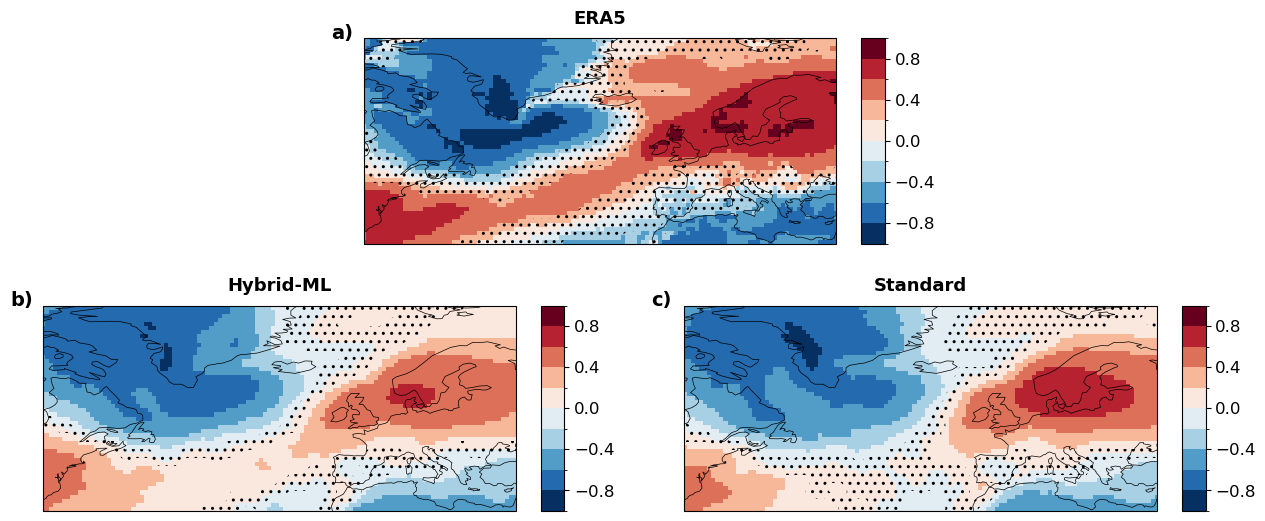

In [29]:
#Plot
row = 1
column = 2

hatching = 1 #show hatching (1) or not (0)

fig = plt.figure(figsize=(15,6))#(22,15))
plt.rcParams.update({'font.size': 12})

fig.subplots_adjust(
    top=0.95,
    bottom=0.08,
    hspace=0.05       # ← tighten vertical distance
)
# Create a 2×2 grid, but allow flexible spanning
gs = GridSpec(2, 4, height_ratios=[1, 1], figure=fig, wspace=0.6)

#=================== ERA ===================
plot_data = r_era
pvals = p_era

ax1 = fig.add_subplot(gs[0, 1:3], projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)
# ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax1.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax1.coastlines(resolution='110m',lw=0.5,color='k'); ax1.set_facecolor('w')
plt.xlim([lon_min, lon_max])
plt.ylim([lat_min, lat_max])
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
plt.colorbar(pcm,cax=cax)
ax1.text(0.5, 1.05, 'ERA5', transform=ax1.transAxes,
        ha='center', va='bottom', fontsize=13, fontweight='bold')

#=================== ML ===================
plot_data = r_ML
pvals = p_ML

ax2 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)
# ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax2.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax2.coastlines(resolution='110m',lw=0.5,color='k'); ax2.set_facecolor('w')
plt.xlim([lon_min, lon_max])
plt.ylim([lat_min, lat_max])
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
plt.colorbar(pcm,cax=cax)
ax2.text(0.5, 1.05, 'Hybrid-ML', transform=ax2.transAxes,
        ha='center', va='bottom', fontsize=13, fontweight='bold')

#=================== MPI ===================
plot_data = r_MPI
pvals = p_MPI

ax3 = fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree())
# ---- CORRELATION MAP ----
pcm = plt.pcolormesh(
    plot_data.lon,
    plot_data.lat,
    plot_data,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)
# ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
if hatching == 1:
    # ---- HATCHING FOR NON-SIGNIFICANT GRIDS ----
    mask = (pvals > 0.05).astype(int)   # numeric mask required
    ax3.contourf(
        plot_data.lon,
        plot_data.lat,
        mask,
        levels=[0.5, 1.5],          # everything >0.5 is considered non-significant
        colors='none',               # no color fill
        hatches=['..'],             # hatching style
        transform=ccrs.PlateCarree(),
        zorder=10
    )
ax3.coastlines(resolution='110m',lw=0.5,color='k'); ax3.set_facecolor('w')
plt.xlim([lon_min, lon_max])
plt.ylim([lat_min, lat_max])
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.25, axes_class=maxes.Axes)
plt.colorbar(pcm,cax=cax)
ax3.text(0.5, 1.05, 'Standard', transform=ax3.transAxes,
        ha='center', va='bottom', fontsize=13, fontweight='bold')

#=================== a,b,c ===================

ax1.text(
    -0.07, 1.07, 'a)',   # position (x,y)
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax2.text(
    -0.07, 1.07, 'b)',   # position (x,y)
    transform=ax2.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax3.text(
    -0.07, 1.07, 'c)',   # position (x,y)
    transform=ax3.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

plt.savefig(plot_path+'z500_eof_pc_tas_'+seas+'_correlation_1leadyear_period_%i-%i_anomaly_ref_%i-%i'%(time_min,time_max,ref_min,ref_max),bbox_inches="tight",dpi=100) 